# 3\. Joins between Tables

## Task 3.1

- Take another look at the results from task 1.5.
- They contain a category no. but no descriptive category name.
- You can find the corresponding name in the ProductCategory table.
- Extends the query to add the descriptive category name as the "Category Name" column.

In [13]:
-- Query from Task 1.5
USE AdventureWorks2017
GO

SELECT 
       psc.Name AS 'Subcategory Name', 

       pc.Name AS 'Category Name',
       psc.ModifiedDate,
       psc.ProductSubcategoryID, 
       psc.ProductCategoryID
FROM   Production.ProductSubcategory psc INNER JOIN Production.ProductCategory pc
ON     psc.ProductCategoryID=pc.ProductCategoryID
WHERE psc.Name LIKE '%Bike%'
ORDER BY [Subcategory Name];


Commands completed successfully.

(5 rows affected)

Total execution time: 00:00:00.026

Subcategory Name,Category Name,ModifiedDate,ProductSubcategoryID,ProductCategoryID
Bike Racks,Accessories,2008-04-30 00:00:00.000,26,4
Bike Stands,Accessories,2008-04-30 00:00:00.000,27,4
Mountain Bikes,Bikes,2008-04-30 00:00:00.000,1,1
Road Bikes,Bikes,2008-04-30 00:00:00.000,2,1
Touring Bikes,Bikes,2008-04-30 00:00:00.000,3,1


## Task 3.2

- Now we extend the query from task 3.1 with details about the product in question.
- To do this, add the ProductID as "Product ID" and the product name as "Product Name" from the Product table.

In [2]:
USE AdventureWorks2017
GO

SELECT 
       pp.Name AS 'Product Name',
       pp.ProductID AS 'Product ID',
       psc.Name AS 'Subcategory Name', 
       pc.Name AS 'Category Name',
       psc.ModifiedDate,
       psc.ProductSubcategoryID, 
       psc.ProductCategoryID
FROM   Production.ProductSubcategory psc 
INNER JOIN Production.ProductCategory pc
ON     psc.ProductCategoryID=pc.ProductCategoryID
INNER JOIN Production.Product pp
ON     psc.ProductSubcategoryID=pp.ProductSubcategoryID
WHERE psc.Name LIKE '%Bike%'
ORDER BY [Subcategory Name];


Commands completed successfully.

(99 rows affected)

Total execution time: 00:00:00.108

Product Name,Product ID,Subcategory Name,Category Name,ModifiedDate,ProductSubcategoryID,ProductCategoryID
Hitch Rack - 4-Bike,876,Bike Racks,Accessories,2008-04-30 00:00:00.000,26,4
All-Purpose Bike Stand,879,Bike Stands,Accessories,2008-04-30 00:00:00.000,27,4
"Mountain-100 Silver, 38",771,Mountain Bikes,Bikes,2008-04-30 00:00:00.000,1,1
"Mountain-100 Silver, 42",772,Mountain Bikes,Bikes,2008-04-30 00:00:00.000,1,1
"Mountain-100 Silver, 44",773,Mountain Bikes,Bikes,2008-04-30 00:00:00.000,1,1
"Mountain-100 Silver, 48",774,Mountain Bikes,Bikes,2008-04-30 00:00:00.000,1,1
"Mountain-100 Black, 38",775,Mountain Bikes,Bikes,2008-04-30 00:00:00.000,1,1
"Mountain-100 Black, 42",776,Mountain Bikes,Bikes,2008-04-30 00:00:00.000,1,1
"Mountain-100 Black, 44",777,Mountain Bikes,Bikes,2008-04-30 00:00:00.000,1,1
"Mountain-100 Black, 48",778,Mountain Bikes,Bikes,2008-04-30 00:00:00.000,1,1


## Task 3.3

- Extend the following Query to make it easier to read: Replace the VendorID and ShipMethodID with the descriptive name.
- The data for the descriptive names can be found in the Vendor and ShipMethod tables.
- This example shows you a self join which is also possible to solfe some specific problems  
    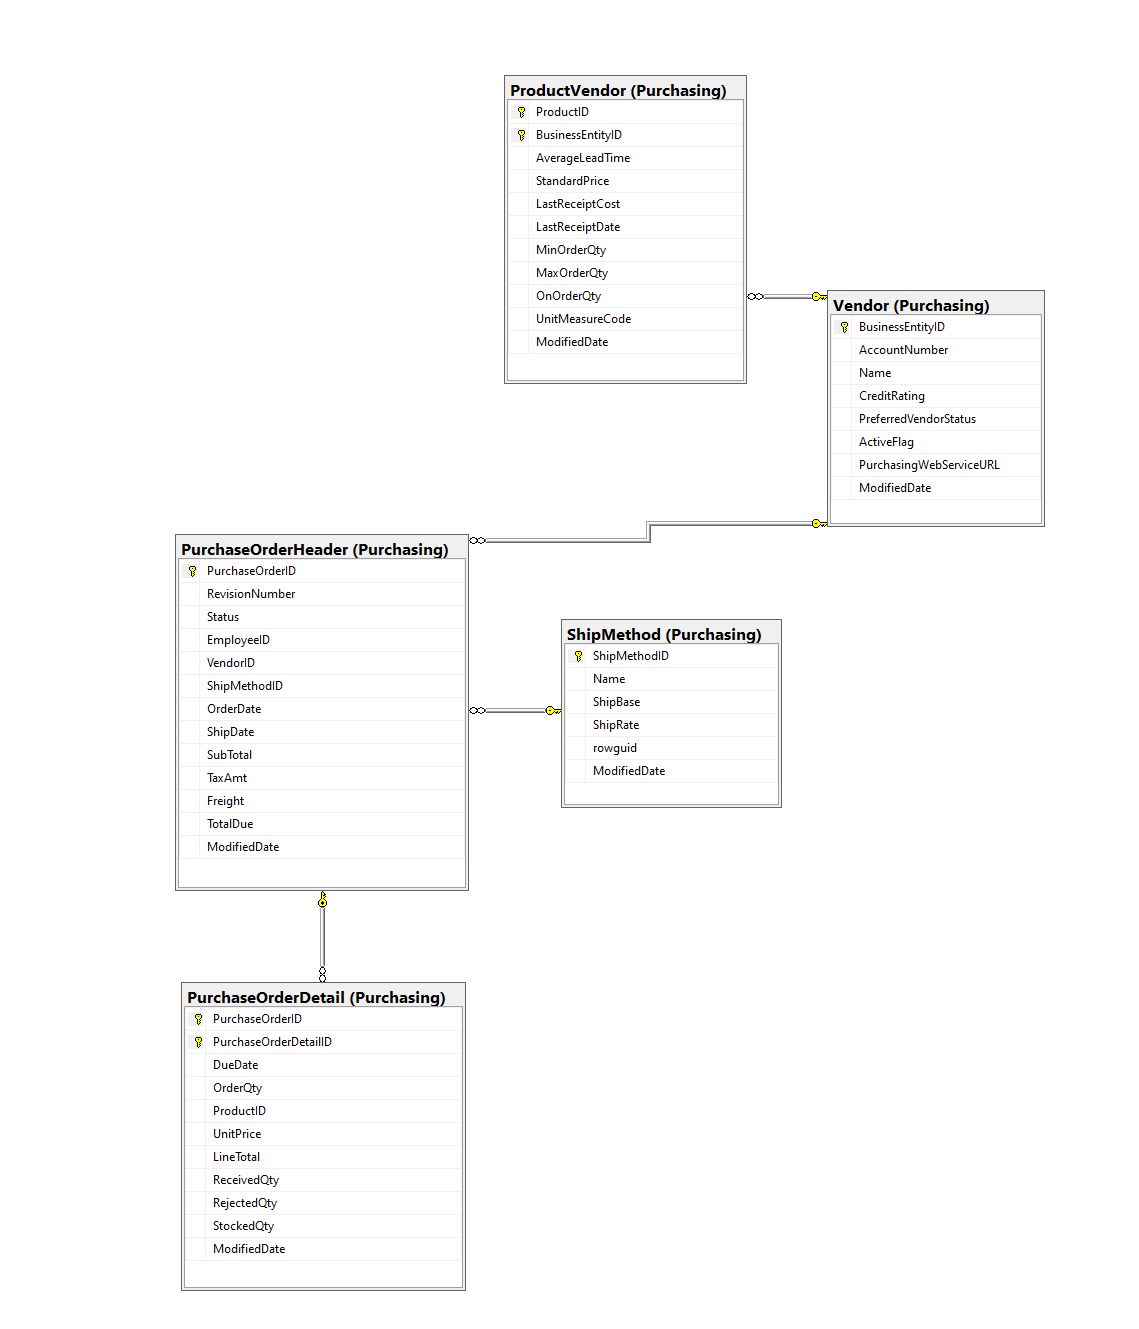

In [26]:
USE AdventureWorks2017
GO

SELECT a.PurchaseOrderID
       , b.PurchaseOrderID
       , sm.Name AS 'Ship Method'
       , pv.Name AS 'Vendor Name'
       , a.VendorID 
       , b.ShipMethodID
FROM Purchasing.PurchaseOrderHeader AS a
INNER JOIN Purchasing.PurchaseOrderHeader AS b
ON a.VendorID = b.VendorID
   AND a.ShipMethodID = b.ShipMethodID
INNER JOIN Purchasing.ShipMethod AS sm
ON a.ShipMethodID = sm.ShipMethodID
INNER JOIN Purchasing.Vendor as pv 
ON a.VendorID = pv.BusinessEntityID
WHERE a.ShipMethodID = sm.ShipMethodID
AND a.VendorID = pv.BusinessEntityID
AND a.PurchaseOrderID < b.PurchaseOrderID




Commands completed successfully.

(86142 rows affected)

Displaying Top 5000 rows.

Total execution time: 00:00:01.196

PurchaseOrderID,PurchaseOrderID,Ship Method,Vendor Name,VendorID,ShipMethodID
2,81,CARGO TRANSPORT 5,Advanced Bicycles,1496,5
2,397,CARGO TRANSPORT 5,Advanced Bicycles,1496,5
2,589,CARGO TRANSPORT 5,Advanced Bicycles,1496,5
2,676,CARGO TRANSPORT 5,Advanced Bicycles,1496,5
2,925,CARGO TRANSPORT 5,Advanced Bicycles,1496,5
2,3774,CARGO TRANSPORT 5,Advanced Bicycles,1496,5
2,3853,CARGO TRANSPORT 5,Advanced Bicycles,1496,5
2,3932,CARGO TRANSPORT 5,Advanced Bicycles,1496,5
2,2747,CARGO TRANSPORT 5,Advanced Bicycles,1496,5
2,2984,CARGO TRANSPORT 5,Advanced Bicycles,1496,5


## Task 3.4

- SQL Server stores its metadata in the sys schema You can find all tables in each database in the sys.tables view and all schemas of the database in the sys.schemas view.
- Using this knowledge, write a query that returns all tables with the associated schema of the AdventureWorks database that contain the word "Business" in the name.

In [37]:
SELECT TOP (1000)
    t.name
    ,s.name
    , t.object_id
FROM sys.tables t 
INNER JOIN sys.schemas s
ON t.schema_id = s.schema_id
WHERE t.name LIKE '%product%'



(16 rows affected)

Total execution time: 00:00:00.047

name,name,object_id
Product,Production,482100758
ProductCategory,Production,722101613
ProductCostHistory,Production,770101784
ProductDescription,Production,834102012
ProductDocument,Production,882102183
ProductInventory,Production,914102297
ProductListPriceHistory,Production,1010102639
SpecialOfferProduct,Sales,1070626857
ProductModel,Production,1074102867
ProductModelIllustration,Production,1122103038


## Task 3.5

- Extend the queries from task 2.4 so that the descriptive name is displayed instead of the ProductSubCategoryID (information can be found in the ProductSubcategory table).
- The field with the descriptive name should have the heading "Subcatname“.

In [41]:
USE AdventureWorks2017
GO

--Code from Exercise 2.4
SELECT
    ps.Name AS 'Subcatname'
    , MIN(p.ListPrice) AS 'Minimum'
    , MAX(p.ListPrice) AS 'Maximum'
    , AVG(p.ListPrice) AS 'Average'
 FROM Production.Product p
 INNER JOIN Production.ProductSubcategory ps
 ON ps.ProductSubcategoryID = p.ProductSubcategoryID
 WHERE p.ProductSubcategoryID IS NOT NULL
 GROUP BY ps.Name;

Commands completed successfully.

(37 rows affected)

Total execution time: 00:00:00.029

Subcatname,Minimum,Maximum,Average
Mountain Bikes,539.99,3399.99,1683.365
Road Bikes,539.99,3578.27,1597.45
Touring Bikes,742.35,2384.07,1425.2481
Handlebars,44.54,120.27,73.89
Bottom Brackets,53.99,121.49,92.24
Brakes,106.50,106.50,106.50
Chains,20.24,20.24,20.24
Cranksets,175.49,404.99,278.99
Derailleurs,91.49,121.46,106.475
Forks,148.22,229.49,184.40
